<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_ML2526/blob/main/Praktikum1/CaliforniaRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import pickle

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['MedHouseValue'] = housing.target

# Dependent Variable
targets = df['MedHouseValue']

# Independent Variable
inputs = df.drop(['MedHouseValue'], axis=1)

# Menampilkan 5 data terbawah
df.tail()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nJumlah Data Training:", X_train.shape[0])
print("Jumlah Data Testing:", X_test.shape[0])



Jumlah Data Training: 14448
Jumlah Data Testing: 6192


In [5]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Model Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\nIntercept:", model.intercept_)
print("Koefisien (Slope):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")


Intercept: 3.6307047193242434
Koefisien (Slope):
MedInc: 6.464516361453105
HouseAge: 0.4937752672816762
AveRooms: -17.217877319205495
AveBedrms: 19.700928184079135
Population: -0.02767764173772522
AveOccup: -4.187733397766777
Latitude: -3.93424541710588
Longitude: -4.354227278281034


In [6]:
y_pred = model.predict(X_test_scaled)


In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== HASIL EVALUASI MODEL ===")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)


=== HASIL EVALUASI MODEL ===
MSE  : 0.5305677824766751
RMSE : 0.7284008391515452
MAE  : 0.5272474538305947
R²   : 0.5957702326061665


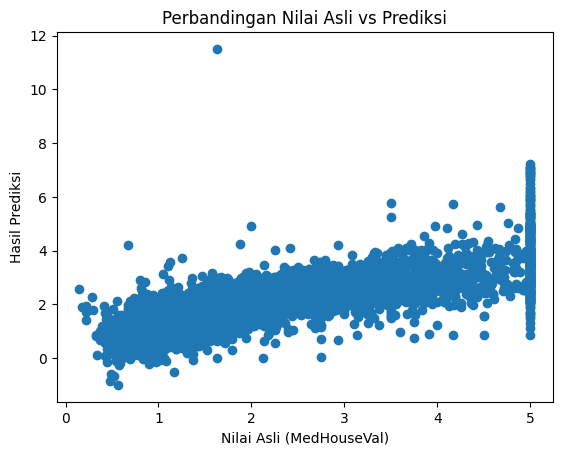

In [8]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Asli (MedHouseVal)")
plt.ylabel("Hasil Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.show()


In [9]:
with open("model_california_linear_regression.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nModel berhasil disimpan sebagai 'model_california_linear_regression.pkl'")


Model berhasil disimpan sebagai 'model_california_linear_regression.pkl'
